# Clash Royale — Train the Matchup Model

Learns **P(deck A beats deck B)** from 1v1 battle outcomes and turns it into the GA's fitness:
the usage-weighted expected win rate against the current meta.

```
card token  = Linear([learned embedding | stats from cards.csv]) + form (base/evo/hero) + side
encoder     = self-attention over all 16 cards of both decks (a deck is a *set* — no positions)
logit(A,B)  = f(A,B) − f(B,A)        # antisymmetric: P(A,B) + P(B,A) = 1 exactly
fitness(D)  = Σ_i weight_i · P(D beats meta_i)
```

**Before running**
1. `conda env update -f environment.yml --prune` (adds PyTorch with CUDA).
2. `data/cards.csv` must exist (`python -m optimizer.build_dataset` or `build_cards.ipynb`).
3. `data/battles.csv` from the data-collection agent — schema in `data/README.md`. The notebook
   uses it automatically when it exists; until then it trains on fabricated battles from a
   planted truth (checks the pipeline, but that model knows nothing about real Clash Royale).

**Run it top to bottom** (Kernel → Restart & Run All). A few minutes end to end on the RTX 4050
for a few hundred thousand battles. Every cell prints what it did.

**Outputs** — `data/meta_decks.csv` (editable) and `data/matchup_model.pt`. Then
`python main.py --fitness model` or pick *Learned matchup model* in the web UI.

In [1]:
import os, sys, math, random, time
from datetime import datetime, timezone

# Windows + conda: numpy's MKL and the pip PyTorch wheel each bundle Intel's OpenMP
# runtime, and the second one to initialise aborts the kernel ("OMP: Error #15") the
# moment matplotlib touches numpy. This is the standard workaround; set it before torch.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import torch
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))  # project root (this notebook lives in notebooks/)
from optimizer import config
from optimizer.cr_api import load_card_pool
from optimizer.battles import load_battles, make_synthetic_battles
from optimizer.meta import build_meta_decks, save_meta_decks, load_meta_decks, meta_to_deck
from optimizer.model import MatchupModel, encode_battles, fit, evaluate
from optimizer.learned_fitness import LearnedFitness
from optimizer.ga import GeneticAlgorithm, random_deck

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "no CUDA -- training will be slower")
print("torch:", torch.__version__)

pool = load_card_pool()
print(f"card pool: {len(pool)} cards ({len(pool.champion_ids)} champions, {len(pool.evolvable_ids)} evolvable)")

device: cuda | NVIDIA GeForce RTX 4050 Laptop GPU
torch: 2.11.0+cu128
card pool: 123 cards (8 champions, 42 evolvable)


## 1. Battles
Real data from `data/battles.csv` if present, otherwise synthetic (see `USE_SYNTHETIC`).

In [2]:
USE_SYNTHETIC = not config.BATTLES_CSV.exists()   # auto: real data as soon as battles.csv exists
N_SYNTHETIC = 50_000

t0 = time.time()
if USE_SYNTHETIC:
    rows, truth = make_synthetic_battles(pool, N_SYNTHETIC, seed=0)
    dropped = 0
    print("=" * 78 + f"\n  SYNTHETIC DATA -- {config.BATTLES_CSV.name} not found, so these are {len(rows)} fabricated\n"
          "  battles from a planted truth. The model you get knows nothing about real Clash Royale.\n" + "=" * 78)
else:
    rows, dropped = load_battles(config.BATTLES_CSV, pool)
    truth = None
    before = len(rows)
    rows = list({r.battle_id or i: r for i, r in enumerate(rows)}.values())  # defensive dedupe
    print(f"Loaded {before} battles from {config.BATTLES_CSV.name} in {time.time() - t0:.1f}s "
          f"({dropped} dropped: unknown card / bad row; {before - len(rows)} duplicate ids).")
    if len(rows) < 5_000:
        print(f"!! only {len(rows)} battles -- expect a weak model; 50k+ is where it gets interesting.")

rows.sort(key=lambda r: r.battle_time)  # time order, for the split below
n_draw = sum(r.result == 0.5 for r in rows)
hero_share = sum(r.hero_known for r in rows) / max(1, len(rows))
print(f"A-win share {sum(r.result for r in rows) / max(1, len(rows)):.3f} | draws {n_draw} | "
      f"hero form known in {hero_share:.0%} of rows | evo used in "
      f"{sum(bool(r.a_evo) + bool(r.b_evo) for r in rows) / max(1, 2 * len(rows)):.0%} of decks")
HAS_HERO_DATA = hero_share > 0.5
print("has_hero_data:", HAS_HERO_DATA, "(hero slot affects fitness only when True)")

Loaded 77815 battles from battles.csv in 1.8s (0 dropped: unknown card / bad row; 0 duplicate ids).
A-win share 0.501 | draws 9 | hero form known in 100% of rows | evo used in 98% of decks
has_hero_data: True (hero slot affects fitness only when True)


## 2. The meta
The most-played decks, weighted by usage share. Written to `data/meta_decks.csv`; edit that file
by hand to pin archetypes or change weights, and set `REBUILD_META = False` to keep your edits.

In [3]:
REBUILD_META = True
META_DECK_COUNT = config.META_DECK_COUNT   # 300 by default; GA cost per generation grows linearly with it

if REBUILD_META or not config.META_DECKS_CSV.exists():
    meta = build_meta_decks(rows, META_DECK_COUNT, pool)
    save_meta_decks(meta, config.META_DECKS_CSV)
    print(f"Wrote {len(meta)} meta decks to {config.META_DECKS_CSV.name}")
else:
    meta = load_meta_decks(config.META_DECKS_CSV, set(pool.by_id))
    print(f"Loaded {len(meta)} meta decks from {config.META_DECKS_CSV.name} (REBUILD_META=False)")

print(f"\ntop 10 by usage (share of the top-{len(meta)} appearances):")
for m in meta[:10]:
    deck = meta_to_deck(m, pool)
    names = ", ".join(c.name + ("*" if c.id in m.evo else "") for c in sorted(deck.cards, key=lambda c: c.elixir))
    print(f"  {m.weight:6.2%}  {m.label:<28} avg {deck.avg_elixir:.1f} | {names}")
print("  (* = evolved)")

Wrote 300 meta decks to meta_decks.csv

top 10 by usage (share of the top-300 appearances):
   2.89%  Fireball / Hog Rider         avg 2.6 | Skeletons*, Ice Spirit, Ice Golem, The Log, Cannon*, Musketeer, Hog Rider, Fireball
   2.37%  Goblinstein / Fireball       avg 3.1 | Skeletons, Bats*, Barbarian Barrel, Ice Wizard, Minion Giant, Goblin Hut, Fireball, Goblinstein
   1.94%  Archer Queen / Royal Hogs    avg 2.9 | Skeletons, Ice Spirit, The Log, Cannon*, Earthquake, Royal Delivery, Royal Hogs*, Archer Queen
   1.90%  Lightning / Goblinstein      avg 3.2 | Skeletons, Electro Spirit, Barbarian Barrel, Archers*, Minion Giant, Tesla*, Goblinstein, Lightning
   1.74%  Royal Giant / Fireball       avg 3.0 | Skeletons, Electro Spirit, Barbarian Barrel, Royal Ghost*, Fisherman, Hunter, Fireball, Royal Giant*
   1.54%  Hog Rider / Mighty Miner     avg 2.8 | Skeletons, Electro Spirit, Barbarian Barrel, Firecracker*, Earthquake, Hog Rider, Mighty Miner, Tesla*
   1.43%  Fireball / Hog Rider     

## 3. Train / validation split
By time — the last 10 % of battles are held out, so the score below is "how well does this
generalise to the *next* week of ladder", not just to random other battles from the same days.

In [4]:
VAL_FRACTION = 0.10

split = int(len(rows) * (1 - VAL_FRACTION))
train_rows, val_rows = rows[:split], rows[split:]
print(f"train {len(train_rows)} | val {len(val_rows)} "
      f"(val starts {val_rows[0].battle_time if val_rows else 'n/a'})")

train 70033 | val 7782 (val starts 2026-09-11T18:02:37Z)


## 4. Train
Everything here is a knob. `USE_STATS=False` ablates the `cards.csv` features (pure learned
embeddings) — compare the validation log-loss to see whether the stats earn their keep.

**Epochs:** `EPOCHS` is only a cap. Training stops early once validation log-loss hasn't improved
for `PATIENCE` epochs and the best epoch's weights are restored — so a short run means the model
had stopped improving, not that it was cut off. Validation log-loss on a few thousand held-out
battles is noisy (±0.01), so `PATIENCE` is generous; raise it further if the log shows late
improvements. More epochs won't beat more data: the ceiling is how much signal is in the battles.

Speed: the whole dataset lives on the GPU as index tensors, and training runs in bfloat16
autocast (about 8 s/epoch per 350k battles on an RTX 4050).

In [5]:
D_MODEL, N_HEADS, N_LAYERS, D_FF = 64, 4, 2, 128
DROPOUT, CARD_DROPOUT = 0.1, 0.10
USE_STATS = True
EPOCHS, LR, WEIGHT_DECAY, BATCH_SIZE, PATIENCE = 150, 1e-3, 1e-4, 1024, 15
SEED = 0

model = MatchupModel.from_pool(
    pool, d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, d_ff=D_FF,
    dropout=DROPOUT, card_dropout=CARD_DROPOUT, use_stats=USE_STATS,
    has_hero_data=HAS_HERO_DATA,
).to(DEVICE)
print(f"{sum(p.numel() for p in model.parameters()):,} parameters")

t0 = time.time()
train = encode_battles(model, train_rows, DEVICE)
val = encode_battles(model, val_rows, DEVICE)
print(f"encoded {len(train_rows) + len(val_rows)} battles in {time.time() - t0:.1f}s")
print("untrained:", {k: round(v, 4) for k, v in evaluate(model, val).items()})

t0 = time.time()
history = fit(model, train, val, epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
              batch_size=BATCH_SIZE, patience=PATIENCE, seed=SEED)
elapsed = time.time() - t0
print(f"trained {len(history)} epochs in {elapsed:.0f}s "
      f"({len(train_rows) * len(history) / max(elapsed, 1e-9):,.0f} battles/s)")

90,497 parameters
encoded 77815 battles in 1.1s
untrained: {'n': 7782, 'logloss': 0.6934, 'accuracy': 0.4969, 'brier': 0.2501}
epoch   1 | train 0.6782 | val 0.6860 (acc 0.538) | 1.9s
epoch   2 | train 0.6706 | val 0.6828 (acc 0.536) | 1.6s
epoch   3 | train 0.6666 | val 0.6791 (acc 0.545) | 1.6s
epoch   4 | train 0.6642 | val 0.6832 (acc 0.542) | 1.6s
epoch   5 | train 0.6636 | val 0.6799 (acc 0.544) | 1.6s
epoch   6 | train 0.6617 | val 0.6807 (acc 0.544) | 1.6s
epoch   7 | train 0.6611 | val 0.6806 (acc 0.547) | 1.6s
epoch   8 | train 0.6597 | val 0.6793 (acc 0.544) | 1.6s
epoch   9 | train 0.6584 | val 0.6787 (acc 0.552) | 1.6s
epoch  10 | train 0.6564 | val 0.6797 (acc 0.546) | 1.6s
epoch  11 | train 0.6557 | val 0.6815 (acc 0.551) | 1.6s
epoch  12 | train 0.6536 | val 0.6790 (acc 0.558) | 1.6s
epoch  13 | train 0.6525 | val 0.6766 (acc 0.555) | 1.6s
epoch  14 | train 0.6514 | val 0.6793 (acc 0.557) | 1.6s
epoch  15 | train 0.6492 | val 0.6772 (acc 0.557) | 1.6s
epoch  16 | train 

## 5. Evaluate
Log-loss is the number that matters (calibrated probabilities feed the fitness); the coin-flip
baseline is ln 2 ≈ 0.693. Accuracy on real ladder data will be modest (55–65 %) because skill and
tilt dominate single games — that's expected.

validation: log-loss 0.6766 (coin flip 0.6931) | accuracy 0.555 | Brier 0.2422 | n=7782


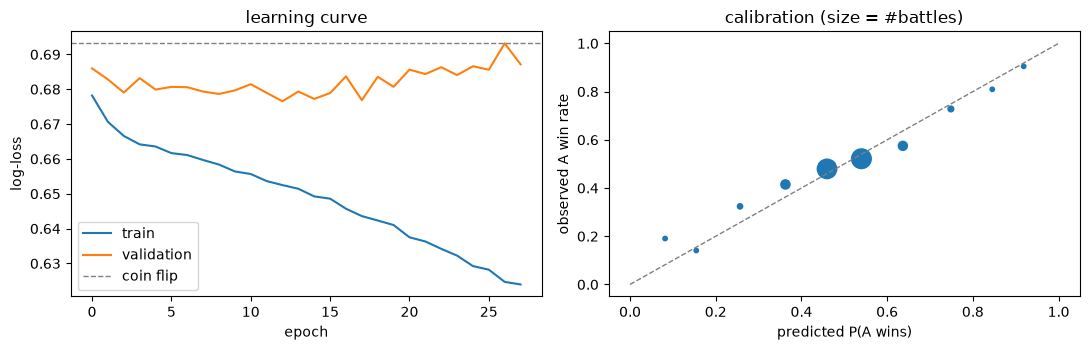

max |P(A,B) + P(B,A) - 1| = 1.19e-07


In [6]:
result = evaluate(model, val)
print(f"validation: log-loss {result['logloss']:.4f} (coin flip 0.6931) | "
      f"accuracy {result['accuracy']:.3f} | Brier {result['brier']:.4f} | n={result['n']}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ax = axes[0]
ax.plot([h["train_logloss"] for h in history], label="train")
ax.plot([h["val_logloss"] for h in history], label="validation")
ax.axhline(math.log(2), ls="--", c="grey", lw=1, label="coin flip")
ax.set_xlabel("epoch"); ax.set_ylabel("log-loss"); ax.legend(); ax.set_title("learning curve")

# calibration: predicted vs observed win rate in 10 bins
with torch.inference_mode():
    p = model.predict_proba(*val[:4]).cpu()
y = val[4].cpu()
bins = torch.clamp((p * 10).long(), max=9)
xs, ys, ns = [], [], []
for b in range(10):
    sel = bins == b
    if sel.any():
        xs.append(p[sel].mean().item()); ys.append(y[sel].mean().item()); ns.append(int(sel.sum()))
ax = axes[1]
ax.plot([0, 1], [0, 1], ls="--", c="grey", lw=1)
ax.scatter(xs, ys, s=[max(10, n / max(ns) * 200) for n in ns])
ax.set_xlabel("predicted P(A wins)"); ax.set_ylabel("observed A win rate"); ax.set_title("calibration (size = #battles)")
plt.tight_layout(); plt.show()

# antisymmetry sanity check
with torch.inference_mode():
    a_idx, a_form, b_idx, b_form = (t[:256] for t in val[:4])
    p_ab = model.predict_proba(a_idx, a_form, b_idx, b_form)
    p_ba = model.predict_proba(b_idx, b_form, a_idx, a_form)
print(f"max |P(A,B) + P(B,A) - 1| = {(p_ab + p_ba - 1).abs().max().item():.2e}")

if truth is not None:  # synthetic only: how close are we to the planted truth?
    true_p = torch.tensor([truth.win_prob(r.a, r.b) for r in val_rows])
    corr = torch.corrcoef(torch.stack([p, true_p]))[0, 1].item()
    print(f"synthetic truth: corr(predicted, true P) = {corr:.3f}")

### Does the model prefer real decks to random ones?
If the meta decks don't out-score random legal decks, something is off.

In [7]:
rng = random.Random(1)
meta_decks = [meta_to_deck(m, pool) for m in meta]
random_decks = [random_deck(pool, rng) for _ in range(len(meta_decks))]

def mean_win_vs_meta(decks):
    a_idx, a_form = model.encode_decks(decks, DEVICE)
    m_idx, m_form = model.encode_decks(meta, DEVICE)
    n, m = len(decks), len(meta)
    with torch.inference_mode():
        p = model.predict_proba(a_idx.repeat_interleave(m, 0), a_form.repeat_interleave(m, 0),
                                m_idx.repeat(n, 1), m_form.repeat(n, 1)).view(n, m)
    w = torch.tensor([x.weight for x in meta], device=DEVICE)
    return (p @ w).mean().item()

print(f"mean expected win rate vs the meta:  meta decks {mean_win_vs_meta(meta_decks):.3f}  |  random legal decks {mean_win_vs_meta(random_decks):.3f}")

mean expected win rate vs the meta:  meta decks 0.478  |  random legal decks 0.377


### Counter probe
For a few cards, which opponent cards hurt the most? Adds card X to random decks and measures the
change in win probability when the opponent holds Y. Real data should surface known counters.

In [8]:
PROBE_CARDS = ["Golem", "Hog Rider", "Balloon", "Lava Hound"]
N_CONTEXTS = 200

name_to_id = {c.name: c.id for c in pool.cards}
rng = random.Random(2)

def probe(card_name, top=5):
    x = name_to_id[card_name]
    others = [c for c in pool.cards if c.id != x]
    ctx = []
    for _ in range(N_CONTEXTS):
        a, b = random_deck(pool, rng), random_deck(pool, rng)
        a_ids = [c.id for c in a.cards if c.id != x][:7] + [x]
        b_ids = [c.id for c in b.cards if c.id != x][:7]
        ctx.append((a_ids, set(a.evolved) & set(a_ids), b_ids, set(b.evolved) & set(b_ids)))
    effects = []
    for y in others:
        pairs_a = [(a_ids, a_evo, set()) for a_ids, a_evo, _, _ in ctx]
        pairs_b = [((b_ids + [y.id])[-8:], b_evo, set()) for _, _, b_ids, b_evo in ctx if y.id not in b_ids]
        pairs_a = pairs_a[:len(pairs_b)]
        if len(pairs_b) < 20:
            continue
        a_idx, a_form = model.encode_decks(pairs_a, DEVICE); b_idx, b_form = model.encode_decks(pairs_b, DEVICE)
        with torch.inference_mode():
            pw = model.predict_proba(a_idx, a_form, b_idx, b_form).mean().item()
        effects.append((pw, y.name))
    effects.sort()
    base = sum(e for e, _ in effects) / len(effects)
    print(f"{card_name}: mean P(win) {base:.3f} | hardest counters: " +
          ", ".join(f"{n} ({p:.2f})" for p, n in effects[:top]))

for name in PROBE_CARDS:
    if name in name_to_id:
        probe(name)

Golem: mean P(win) 0.462 | hardest counters: Zap (0.38), Arrows (0.40), Ronin (0.40), Skeleton Army (0.40), Witch (0.40)
Hog Rider: mean P(win) 0.509 | hardest counters: Zap (0.42), Ronin (0.43), The Log (0.43), Barbarian Barrel (0.44), Skeleton Army (0.44)
Balloon: mean P(win) 0.496 | hardest counters: Zap (0.41), Barbarian Barrel (0.42), Ronin (0.42), The Log (0.42), Arrows (0.43)
Lava Hound: mean P(win) 0.396 | hardest counters: Zap (0.32), Skeleton Army (0.32), Ronin (0.32), Firecracker (0.33), Arrows (0.33)


## 6. Save
Writes `data/matchup_model.pt` — weights, hyperparameters, the card vocabulary and the numbers
above — **every run, overwriting the previous file**. The previous checkpoint is kept as
`matchup_model.prev.pt` so a worse retrain is a rename away from undone. `main.py --fitness model`
and the web UI pick the new file up automatically (they reload whenever it changes).

In [9]:
KEEP_PREVIOUS = True

if KEEP_PREVIOUS and config.MODEL_PATH.exists():
    prev = config.MODEL_PATH.with_suffix(".prev.pt")
    config.MODEL_PATH.replace(prev)
    print(f"previous checkpoint kept as {prev.name}")

model.save(config.MODEL_PATH, meta={
    "val_logloss": float(result["logloss"]),
    "val_accuracy": float(result["accuracy"]),
    "n_train": len(train_rows),
    "n_val": len(val_rows),
    "synthetic": bool(USE_SYNTHETIC),
    "has_hero_data": bool(HAS_HERO_DATA),
    "trained_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
})
print(f"saved {config.MODEL_PATH} ({config.MODEL_PATH.stat().st_size / 1024:.0f} KB)")

previous checkpoint kept as matchup_model.prev.pt
saved C:\Users\jerem\Hackathon 2\clash-royale-deck-optimizer\data\matchup_model.pt (407 KB)


## 7. Smoke test: evolve a deck against the meta
A short GA run with the learned fitness. Fitness is the expected win rate vs the meta decks.

In [10]:
fitness = LearnedFitness(config.MODEL_PATH, config.META_DECKS_CSV, device=DEVICE)
ga = GeneticAlgorithm(pool, fitness, population_size=300, generations=60, seed=0)
t0 = time.time()
best = ga.run(on_generation=lambda g, pop: print(f"  gen {g:3d} | best {ga.fitness(pop[0]):.3f}") if g % 10 == 0 else None)
print(f"{time.time() - t0:.1f}s\n")

print(f"=== Best deck: expected win rate vs meta {ga.fitness(best):.1%} ===")
for card in sorted(best.cards, key=lambda c: (c.elixir, c.name)):
    tag = "CHAMPION" if card.is_champion else {"evo": "EVO", "hero": "HERO"}.get(best.form_of(card), "")
    print(f"   {card.elixir}  {card.name}" + (f"   [{tag}]" if tag else ""))
print(f"   avg elixir {best.avg_elixir:.2f} | valid: {best.is_valid()}")

print("\nworst matchups in the meta:")
for (w, p), m in sorted(zip(fitness.matchups(best), meta), key=lambda t: t[0][1])[:5]:
    print(f"   P(win) {p:.2f} vs {m.label or 'meta deck'} (usage {w:.1%})")

  gen   0 | best 0.574
  gen  10 | best 0.700
  gen  20 | best 0.718
  gen  30 | best 0.724
  gen  40 | best 0.724
  gen  50 | best 0.724
25.2s

=== Best deck: expected win rate vs meta 72.4% ===
   2  Barbarian Barrel
   2  Giant Snowball
   3  Cannon   [EVO]
   4  Dark Prince   [HERO]
   4  Minion Giant
   4  Mortar   [EVO]
   4  Poison
   5  Ram Rider
   avg elixir 3.50 | valid: (True, 'ok')

worst matchups in the meta:
   P(win) 0.58 vs Cannon Cart / Goblinstein (usage 0.7%)
   P(win) 0.59 vs Lightning / Goblinstein (usage 1.9%)
   P(win) 0.59 vs Cannon Cart / Goblinstein (usage 0.7%)
   P(win) 0.60 vs Goblinstein / Fireball (usage 2.4%)
   P(win) 0.60 vs Lightning / Goblinstein (usage 0.2%)


## 8. Counter one specific deck
The same GA, but the "meta" is a single opponent: the fitness is simply **P(deck beats TARGET)**.
Write the target as card names — `*` marks the evolved form, `^` the hero form (champions need no
mark). Uses the checkpoint saved above. Note the model was trained on ladder matchups, so a
99 % answer means "the model is very confident", not a guarantee — sanity-check it in the
Matchups tab of the UI.

> If the import below fails with `cannot import name ...`, the kernel is older than the code on disk: **restart the kernel, run cell 1, then this cell** (no retraining needed — it loads the saved checkpoint).


In [13]:
from optimizer.meta import deck_from_names
from optimizer.matchup import fitness_against, predict

TARGET = ("Tesla*, Valkyrie, Fireball, The Log, Hog Rider, Skeletons, Mirror, Executioner")
POPULATION, GENERATIONS, GA_SEED = 1000, 150, 0

target = deck_from_names(TARGET, pool)
target_deck = meta_to_deck(target, pool)
print("target:", ", ".join(c.name + ("*" if c.id in target.evo else "^" if c.id in target.hero else "")
                           for c in sorted(target_deck.cards, key=lambda c: c.elixir)))

vs_target = fitness_against(target)  # fitness = P(deck beats target); batched on the GPU
ga = GeneticAlgorithm(pool, vs_target, population_size=POPULATION, generations=GENERATIONS, seed=GA_SEED)
t0 = time.time()
best = ga.run(on_generation=lambda g, pop: print(f"  gen {g:3d} | best P(win) {ga.fitness(pop[0]):.3f}") if g % 25 == 0 else None)
print(f"{time.time() - t0:.1f}s\n")

print(f"=== Best counter deck: P(beats target) = {ga.fitness(best):.1%} ===")
for card in sorted(best.cards, key=lambda c: (c.elixir, c.name)):
    tag = "CHAMPION" if card.is_champion else {"evo": "EVO", "hero": "HERO"}.get(best.form_of(card), "")
    print(f"   {card.elixir}  {card.name}" + (f"   [{tag}]" if tag else ""))
print(f"   avg elixir {best.avg_elixir:.2f} | valid: {best.is_valid()}")
print(f"\nsymmetry check: P(target beats it) = {predict(target_deck, best):.3f}")

# The same deck's standing against the whole ladder meta, for perspective.
ladder = LearnedFitness(config.MODEL_PATH, config.META_DECKS_CSV, device=DEVICE)
print(f"vs the ladder meta: {ladder(best):.1%} expected win rate")

target: Mirror, Skeletons, The Log, Tesla*, Valkyrie, Fireball, Hog Rider, Executioner
  gen   0 | best P(win) 0.717
  gen  25 | best P(win) 0.873
  gen  50 | best P(win) 0.873
  gen  75 | best P(win) 0.873
  gen 100 | best P(win) 0.873
  gen 125 | best P(win) 0.873
10.5s

=== Best counter deck: P(beats target) = 87.3% ===
   2  Barbarian Barrel
   2  Giant Snowball
   3  Arrows
   4  Baby Dragon   [EVO]
   4  Dark Prince   [HERO]
   4  Freeze
   4  Mortar   [EVO]
   5  Ram Rider
   avg elixir 3.50 | valid: (True, 'ok')

symmetry check: P(target beats it) = 0.127
vs the ladder meta: 70.8% expected win rate
